In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("C:/Users/zekhe/Downloads/medical_examination.csv")

In [6]:
df["overweight"] = np.where(df["weight"] / (df["height"]**2) > 25, 1, 0)

In [7]:
df["gluc"] = np.where(df["gluc"] > 1, 1, 0)

In [8]:
df["cholesterol"] = np.where(df["cholesterol"] > 1, 1, 0)

In [12]:
df_cat = pd.melt(df, value_vars= ["cholesterol", "gluc", "smoke", "alco", "active", "overweight"])

In [13]:
df_cat = df_cat.groupby(["variable", "value"]).size().reset_index(name="total")

In [17]:
df_cat = ((pd.melt(df, id_vars=["cardio"],value_vars=["cholesterol", "gluc", "smoke", "alco", "active", "overweight"])).groupby(["cardio","variable","value"]).size()).reset_index(name="total")

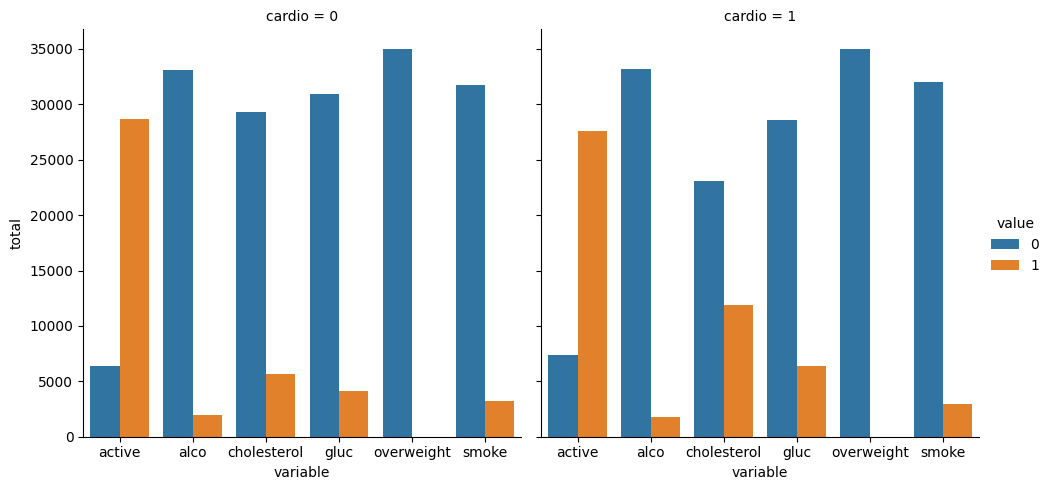

In [18]:
fig = sns.catplot(x= "variable", y = "total", hue = "value", col = "cardio", data = df_cat, kind = "bar").fig

In [31]:
df_heat = df[(df["ap_hi"] >= df["ap_lo"]) & (df['height'] >= df['height'].quantile(0.025)) & (df['height'] < df['height'].quantile(0.975)) & (df['weight'] >= df['weight'].quantile(0.025)) & (df['weight'] < df['weight'].quantile(0.975))]

In [32]:
corr = df_heat.corr(numeric_only= True)

In [34]:
mask = np.triu(np.ones_like(corr, dtype=bool))

<Axes: >

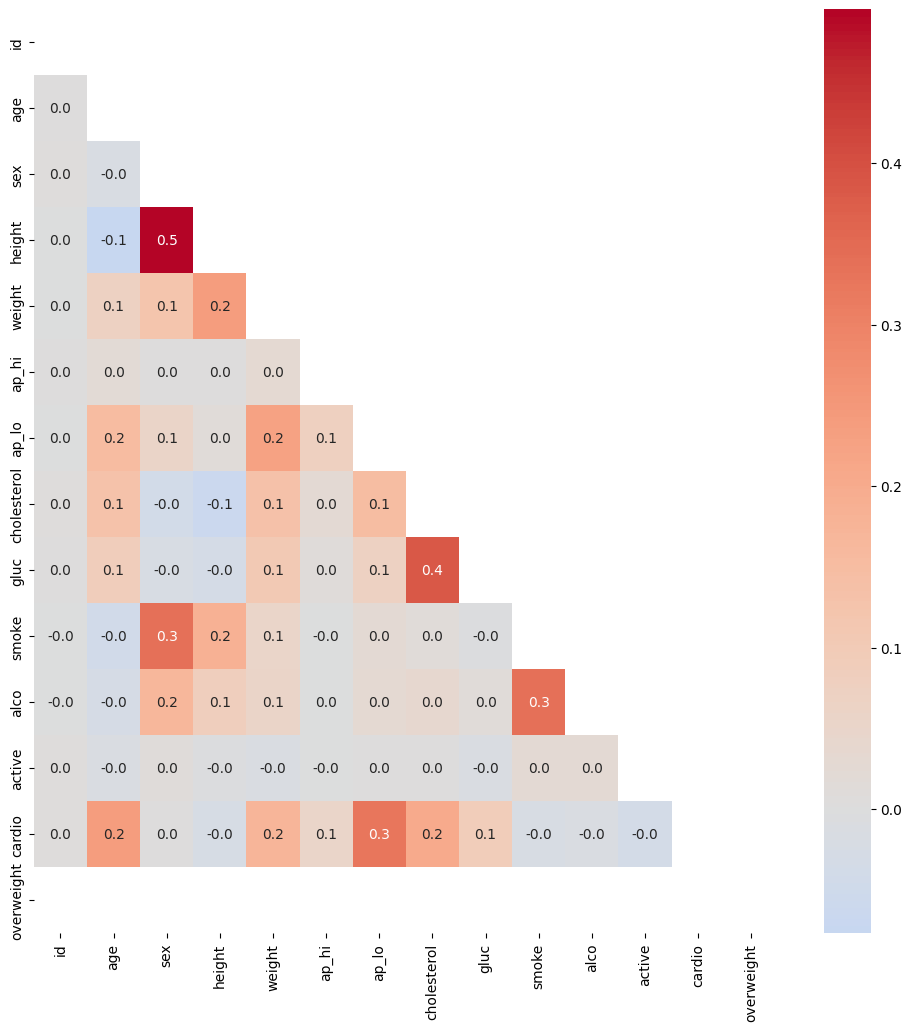

In [35]:
fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(corr,mask=mask,annot=True,  fmt=".1f", center=0,cmap="coolwarm")
